# Phase 1 EDA — Data Validation

**Purpose:** Inspect raw AIS and weather data to confirm it is usable before building features.

This notebook does NOT transform data. It only reads and reports.

Checks performed:
1. Column inventory
2. Null / missing value audit
3. Timestamp parsing
4. Coordinate sanity (lat/lon in valid range)
5. Speed distribution (AIS)
6. Weather variable distributions
7. Port coverage summary

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make sure src/ is importable when running from the notebooks/ folder
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config_loader import load_config

# Notebook display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)

config = load_config()
print('Config loaded. Ports:', [p['name'] for p in config['ports']])

Config loaded. Ports: ['Los Angeles', 'Rotterdam', 'Singapore', 'Shanghai', 'Hamburg']


---
## 1. Load Raw AIS Data

In [2]:
ais_dir = PROJECT_ROOT / config['paths']['raw_ais']
ais_files = list(ais_dir.glob('*.csv'))

print(f'AIS directory : {ais_dir}')
print(f'Files found   : {[f.name for f in ais_files]}')

if not ais_files:
    raise FileNotFoundError(
        f'No AIS CSV files found in {ais_dir}.\n'
        'Run: python src/ingestion/fetch_ais.py'
    )

# Load the first (or only) AIS file
ais = pd.read_csv(ais_files[0], low_memory=False)
print(f'\nLoaded: {ais_files[0].name}')
print(f'Shape : {ais.shape[0]:,} rows × {ais.shape[1]} columns')

AIS directory : C:\port-intelligence\data\raw\ais
Files found   : ['AIS_2023_01_01.csv', 'AIS_2023_01_02.csv', 'AIS_2023_01_03.csv', 'AIS_2023_01_04.csv', 'AIS_2023_01_05.csv', 'ais_data.csv']

Loaded: AIS_2023_01_01.csv
Shape : 8,156,509 rows × 17 columns


### 1a. Column Inventory

In [3]:
print('── Column names and dtypes ──')
print(ais.dtypes.to_string())
print('\n── First 3 rows ──')
ais.head(3)

── Column names and dtypes ──
MMSI                  int64
BaseDateTime         object
LAT                 float64
LON                 float64
SOG                 float64
COG                 float64
Heading             float64
VesselName           object
IMO                  object
CallSign             object
VesselType          float64
Status              float64
Length              float64
Width               float64
Draft               float64
Cargo               float64
TransceiverClass     object

── First 3 rows ──


,MMSI,BaseDateTime,LAT,LON,SOG,COG,Heading,VesselName,IMO,CallSign,VesselType,Status,Length,Width,Draft,Cargo,TransceiverClass
0,368926035,2023-01-01T00:00:05,38.6516,-90.1796,0.1000,360.0000,511.0000,KIMMSWICK,NaN,AENA,33.0000,15.0000,NaN,NaN,NaN,33.0000,A
1,367647050,2023-01-01T00:00:04,30.1651,-90.9994,6.3000,161.4000,511.0000,USS CAIRO,NaN,WDH7325,31.0000,0.0000,20.0000,NaN,NaN,31.0000,A
2,352001704,2023-01-01T00:00:04,28.9196,-94.3703,14.7000,97.5000,97.0000,ENEOS EXPLORER,IMO9935492,3E2723,80.0000,0.0000,230.0000,36.0000,11.7000,80.0000,A


### 1b. Null Value Audit

In [4]:
null_counts = ais.isnull().sum()
null_pct    = (null_counts / len(ais) * 100).round(2)

null_df = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_df = null_df[null_df['null_count'] > 0].sort_values('null_pct', ascending=False)

if null_df.empty:
    print('✓ No null values found in AIS data.')
else:
    print(f'Columns with nulls ({len(null_df)} of {len(ais.columns)}):')
    display(null_df)

    # Flag columns with >20% missing — these need attention in Phase 2
    high_null = null_df[null_df['null_pct'] > 20]
    if not high_null.empty:
        print(f'\n⚠ WARNING: {len(high_null)} column(s) are >20% null:')
        print(high_null.index.tolist())

Columns with nulls (9 of 17):


,null_count,null_pct
Draft,5140664,63.0300
IMO,3863328,47.3600
Status,2045432,25.0800
Cargo,2041484,25.0300
Width,1314748,16.1200
CallSign,1008400,12.3600
Length,466779,5.7200
VesselName,13742,0.1700
VesselType,1053,0.0100



⚠ WARNING: 4 column(s) are >20% null:
['Draft', 'IMO', 'Status', 'Cargo']


### 1c. Timestamp Parsing

AIS data must have parseable timestamps. We check that the column exists,
converts to datetime without errors, and covers a sensible date range.

In [5]:
# Common timestamp column names in AIS datasets
TIMESTAMP_CANDIDATES = ['TIMESTAMP', 'timestamp', 'Timestamp', 'BaseDateTime', 'time', 'Time', 'DATE']

ts_col = None
for col in TIMESTAMP_CANDIDATES:
    if col in ais.columns:
        ts_col = col
        break

if ts_col is None:
    print(f'⚠ No timestamp column found. Checked: {TIMESTAMP_CANDIDATES}')
    print(f'  Available columns: {list(ais.columns)}')
    print('  Update TIMESTAMP_CANDIDATES above with the correct column name.')
else:
    print(f'Timestamp column found: "{ts_col}"')
    ais[ts_col] = pd.to_datetime(ais[ts_col], errors='coerce')

    parse_failures = ais[ts_col].isnull().sum()
    if parse_failures > 0:
        print(f'⚠ {parse_failures:,} rows failed timestamp parsing ({parse_failures/len(ais)*100:.1f}%)')
    else:
        print('✓ All timestamps parsed successfully.')

    print(f'\nDate range:')
    print(f'  Earliest : {ais[ts_col].min()}')
    print(f'  Latest   : {ais[ts_col].max()}')
    print(f'  Span     : {(ais[ts_col].max() - ais[ts_col].min()).days} days')

Timestamp column found: "BaseDateTime"
✓ All timestamps parsed successfully.

Date range:
  Earliest : 2023-01-01 00:00:00
  Latest   : 2023-01-01 23:59:59
  Span     : 0 days


### 1d. Coordinate Sanity Check

Valid latitude: -90 to +90. Valid longitude: -180 to +180.
Out-of-range values indicate corrupted rows.

Lat column: "LAT"  |  Lon column: "LON"

Invalid latitudes  (< -90 or > +90) : 0 rows
Invalid longitudes (< -180 or > +180): 0 rows
✓ All coordinates are in valid range.

Lat range : 2.3881 → 71.2290
Lon range : -177.7998 → 170.3928


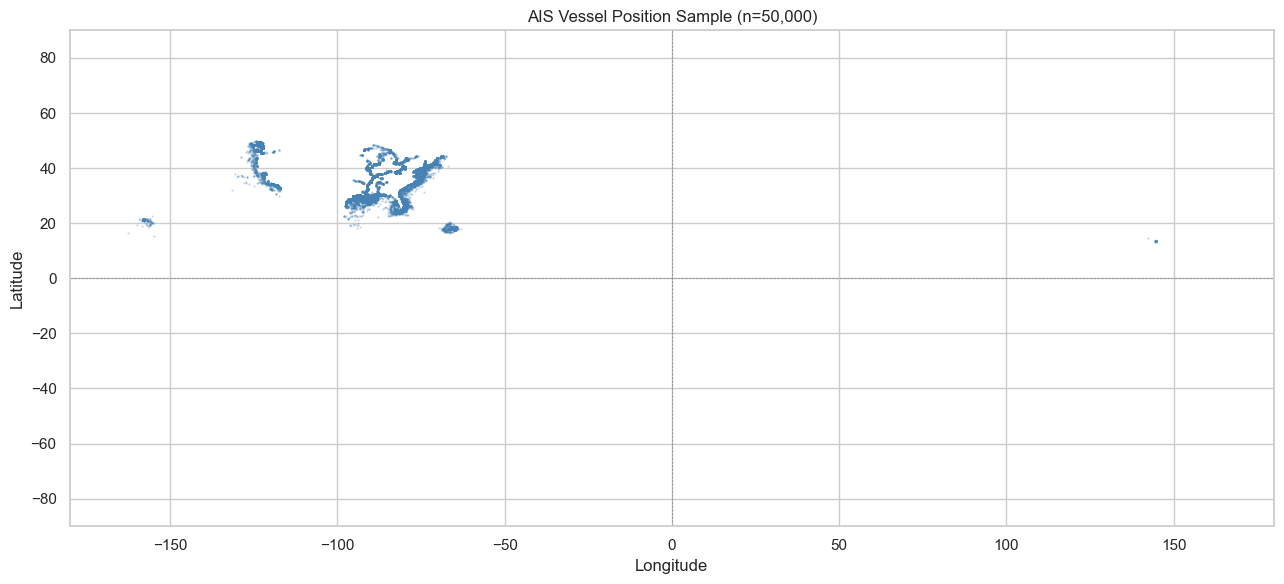

In [6]:
# Common coordinate column names
LAT_CANDIDATES = ['LAT', 'lat', 'Lat', 'latitude', 'Latitude', 'LATITUDE']
LON_CANDIDATES = ['LON', 'lon', 'Lon', 'longitude', 'Longitude', 'LONGITUDE']

lat_col = next((c for c in LAT_CANDIDATES if c in ais.columns), None)
lon_col = next((c for c in LON_CANDIDATES if c in ais.columns), None)

if lat_col is None or lon_col is None:
    print(f'⚠ Could not find lat/lon columns.')
    print(f'  Available: {list(ais.columns)}')
    print(f'  Update LAT_CANDIDATES / LON_CANDIDATES above.')
else:
    print(f'Lat column: "{lat_col}"  |  Lon column: "{lon_col}"')

    invalid_lat = ais[(ais[lat_col] < -90) | (ais[lat_col] > 90)]
    invalid_lon = ais[(ais[lon_col] < -180) | (ais[lon_col] > 180)]

    print(f'\nInvalid latitudes  (< -90 or > +90) : {len(invalid_lat):,} rows')
    print(f'Invalid longitudes (< -180 or > +180): {len(invalid_lon):,} rows')

    if len(invalid_lat) == 0 and len(invalid_lon) == 0:
        print('✓ All coordinates are in valid range.')

    print(f'\nLat range : {ais[lat_col].min():.4f} → {ais[lat_col].max():.4f}')
    print(f'Lon range : {ais[lon_col].min():.4f} → {ais[lon_col].max():.4f}')

    # Plot coordinate scatter — gives a rough world map of the data coverage
    fig, ax = plt.subplots(figsize=(13, 6))
    sample = ais.sample(min(50_000, len(ais)), random_state=42)
    ax.scatter(sample[lon_col], sample[lat_col], s=0.3, alpha=0.3, color='steelblue')
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title(f'AIS Vessel Position Sample (n={len(sample):,})')
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
    plt.tight_layout()
    plt.show()

### 1e. Speed Distribution

Speed in AIS data is in knots. Expected range: 0 (anchored) to ~25 (fast container ship).
Values above 50 are almost certainly noise or data errors.

Speed column: "SOG"

Descriptive statistics:
count   8156509.0000
mean          1.8900
std           6.3600
min           0.0000
25%           0.0000
50%           0.0000
75%           0.1000
max         102.3000

Outlier check:
  Speed > 50 knots : 20,308 rows (0.25%)
  Speed < 0        : 0 rows
  Speed == 0       : 5,560,862 rows  (anchored/moored vessels)
  Speed < 3 knots  : 6,740,719 rows  (slow/waiting — key for Phase 2)


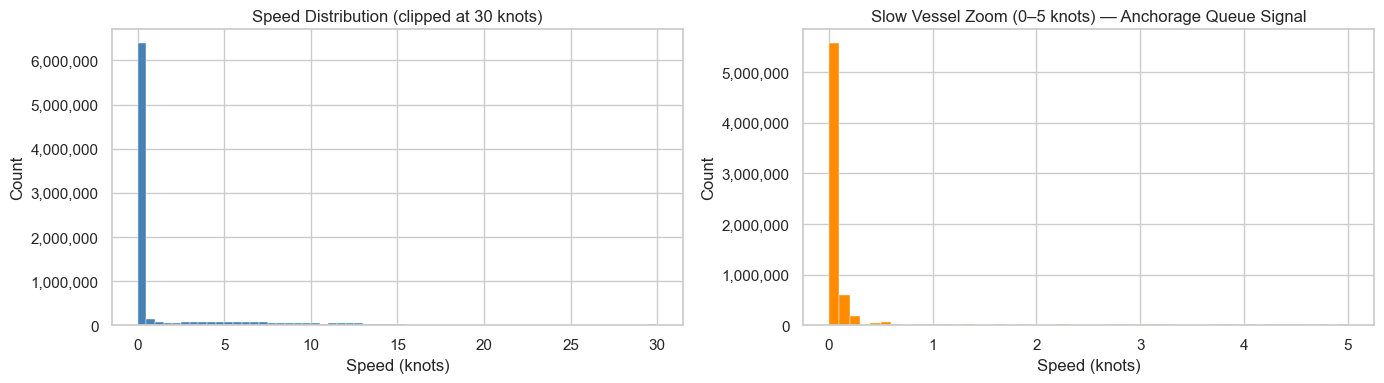

In [7]:
SPEED_CANDIDATES = ['SPEED', 'speed', 'Speed', 'SOG', 'sog', 'speed_over_ground']
speed_col = next((c for c in SPEED_CANDIDATES if c in ais.columns), None)

if speed_col is None:
    print(f'⚠ No speed column found. Checked: {SPEED_CANDIDATES}')
    print(f'  Available columns: {list(ais.columns)}')
else:
    print(f'Speed column: "{speed_col}"')

    speed = pd.to_numeric(ais[speed_col], errors='coerce')
    print(f'\nDescriptive statistics:')
    print(speed.describe().round(2).to_string())

    # Outlier check
    above_50  = (speed > 50).sum()
    negative  = (speed < 0).sum()
    print(f'\nOutlier check:')
    print(f'  Speed > 50 knots : {above_50:,} rows ({above_50/len(ais)*100:.2f}%)')
    print(f'  Speed < 0        : {negative:,} rows')
    print(f'  Speed == 0       : {(speed == 0).sum():,} rows  (anchored/moored vessels)')
    print(f'  Speed < 3 knots  : {(speed < 3).sum():,} rows  (slow/waiting — key for Phase 2)')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Full distribution (capped at 30 for readability)
    speed_clipped = speed.clip(upper=30)
    axes[0].hist(speed_clipped.dropna(), bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[0].set_title('Speed Distribution (clipped at 30 knots)')
    axes[0].set_xlabel('Speed (knots)')
    axes[0].set_ylabel('Count')
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Slow-vessel zoom (0–5 knots) — this is the anchorage queue signal
    slow = speed[speed <= 5]
    axes[1].hist(slow.dropna(), bins=50, color='darkorange', edgecolor='white', linewidth=0.3)
    axes[1].set_title('Slow Vessel Zoom (0–5 knots) — Anchorage Queue Signal')
    axes[1].set_xlabel('Speed (knots)')
    axes[1].set_ylabel('Count')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.show()

---
## 2. Load Raw Weather Data

In [8]:
weather_dir   = PROJECT_ROOT / config['paths']['raw_weather']
weather_files = sorted(weather_dir.glob('*.csv'))

print(f'Weather directory : {weather_dir}')
print(f'Files found       : {[f.name for f in weather_files]}')

if not weather_files:
    raise FileNotFoundError(
        f'No weather CSV files found in {weather_dir}.\n'
        'Run: python src/ingestion/fetch_weather.py'
    )

# Combine all ports into one DataFrame for easier inspection
weather_dfs = [pd.read_csv(f) for f in weather_files]
weather = pd.concat(weather_dfs, ignore_index=True)

print(f'\nCombined shape: {weather.shape[0]:,} rows × {weather.shape[1]} columns')
print(f'Ports loaded  : {weather["port"].unique().tolist()}')
weather.head(3)

Weather directory : C:\port-intelligence\data\raw\weather
Files found       : ['weather_hamburg.csv', 'weather_los_angeles.csv', 'weather_rotterdam.csv', 'weather_shanghai.csv', 'weather_singapore.csv']

Combined shape: 43,800 rows × 8 columns
Ports loaded  : ['Hamburg', 'Los Angeles', 'Rotterdam', 'Shanghai', 'Singapore']


,timestamp,windspeed_10m,winddirection_10m,precipitation,weathercode,port,lat,lon
0,2023-01-01T00:00,30.2000,231,0.0000,3,Hamburg,53.5753,9.8689
1,2023-01-01T01:00,30.9000,228,0.0000,3,Hamburg,53.5753,9.8689
2,2023-01-01T02:00,31.6000,229,0.0000,3,Hamburg,53.5753,9.8689


### 2a. Null Audit

In [9]:
null_counts = weather.isnull().sum()
null_pct    = (null_counts / len(weather) * 100).round(2)
null_df     = pd.DataFrame({'null_count': null_counts, 'null_pct': null_pct})
null_df     = null_df[null_df['null_count'] > 0].sort_values('null_pct', ascending=False)

if null_df.empty:
    print('✓ No null values in weather data.')
else:
    display(null_df)

✓ No null values in weather data.


### 2b. Timestamp Parsing

In [10]:
weather['timestamp'] = pd.to_datetime(weather['timestamp'], errors='coerce')

parse_failures = weather['timestamp'].isnull().sum()
print(f'Timestamp parse failures: {parse_failures}')

print(f'\nDate range per port:')
print(
    weather.groupby('port')['timestamp']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'earliest', 'max': 'latest', 'count': 'rows'})
    .to_string()
)

Timestamp parse failures: 0

Date range per port:
              earliest              latest  rows
port                                            
Hamburg     2023-01-01 2023-12-31 23:00:00  8760
Los Angeles 2023-01-01 2023-12-31 23:00:00  8760
Rotterdam   2023-01-01 2023-12-31 23:00:00  8760
Shanghai    2023-01-01 2023-12-31 23:00:00  8760
Singapore   2023-01-01 2023-12-31 23:00:00  8760


### 2c. Weather Variable Distributions

Numeric weather columns: ['windspeed_10m', 'winddirection_10m', 'precipitation', 'weathercode']

Descriptive statistics:


,windspeed_10m,winddirection_10m,precipitation,weathercode
count,43800.0000,43800.0000,43800.0000,43800.0000
mean,12.2400,183.4700,0.1700,13.4500
std,6.8400,99.4700,0.7200,21.8000
min,0.0000,1.0000,0.0000,0.0000
25%,7.1000,103.0000,0.0000,1.0000
50%,11.0000,191.0000,0.0000,3.0000
75%,16.0000,262.0000,0.0000,3.0000
max,55.1000,360.0000,22.8000,75.0000


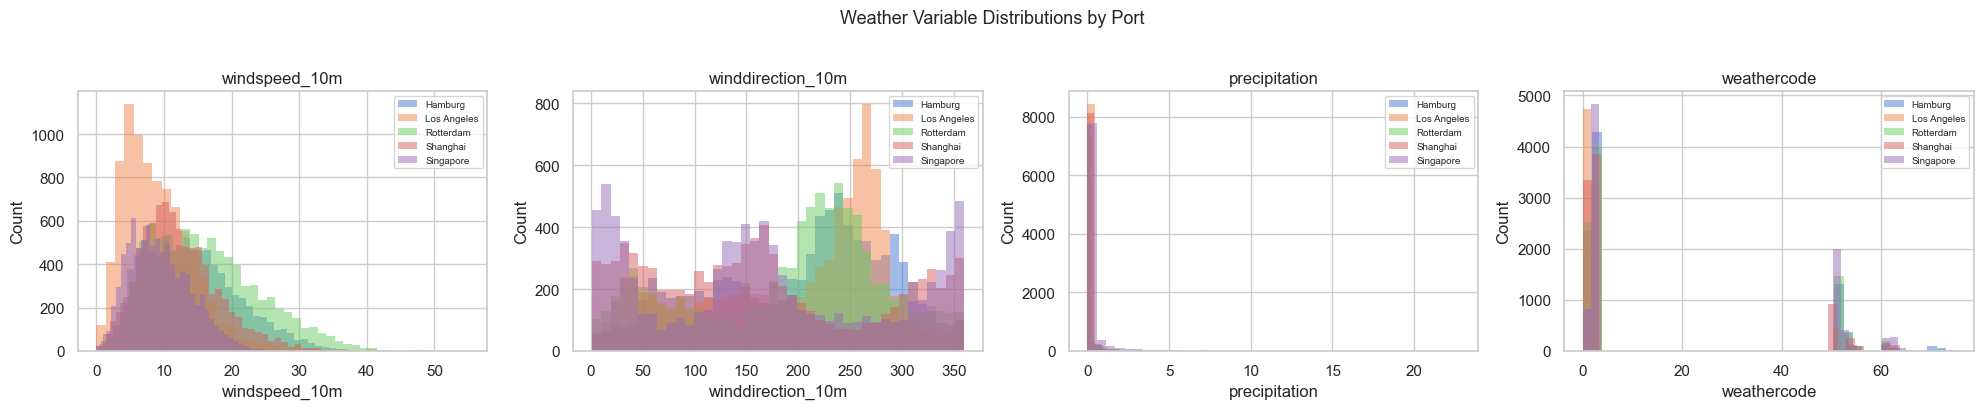

In [11]:
numeric_cols = weather.select_dtypes(include='number').columns.tolist()
# Remove coordinate columns from plots
plot_cols = [c for c in numeric_cols if c not in ('lat', 'lon')]

print(f'Numeric weather columns: {plot_cols}')
print('\nDescriptive statistics:')
display(weather[plot_cols].describe().round(2))

# One plot per variable, all ports overlaid
ports_in_data = weather['port'].unique()
colors = sns.color_palette('muted', len(ports_in_data))
port_color = dict(zip(ports_in_data, colors))

fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 4))
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    for port in ports_in_data:
        subset = weather[weather['port'] == port][col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, label=port, color=port_color[port], edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(fontsize=7)

plt.suptitle('Weather Variable Distributions by Port', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 3. Phase 1 Validation Summary

In [12]:
print('=' * 55)
print('  PHASE 1 VALIDATION SUMMARY')
print('=' * 55)
print(f'  AIS rows loaded         : {len(ais):,}')
print(f'  AIS columns             : {len(ais.columns)}')
print(f'  Weather rows (all ports): {len(weather):,}')
print(f'  Weather ports covered   : {weather["port"].nunique()}')
print()
print('  Ready for Phase 2: Feature Engineering')
print('  Next steps:')
print('    - Engineer speed_drop_ratio from AIS')
print('    - Engineer time_in_anchorage_zone from AIS')
print('    - Build weather_severity_score from wind + precipitation')
print('    - Merge AIS + weather on date + port proximity')
print('=' * 55)

  PHASE 1 VALIDATION SUMMARY
  AIS rows loaded         : 8,156,509
  AIS columns             : 17
  Weather rows (all ports): 43,800
  Weather ports covered   : 5

  Ready for Phase 2: Feature Engineering
  Next steps:
    - Engineer speed_drop_ratio from AIS
    - Engineer time_in_anchorage_zone from AIS
    - Build weather_severity_score from wind + precipitation
    - Merge AIS + weather on date + port proximity
